
# Fixed Neighborhood Simulations

This notebook runs the **fixed-neighborhood** VEGF–GLUT1 model and generates the main simulation panels in a clean, reproducible order.

## What this notebook does
- imports the fixed-neighborhood model from the `utils` package
- defines a single editable parameter block
- runs **ESS** simulations across multiple values of neighborhood size `N` and sharing parameter `q`
- saves a combined Excel workbook for the ESS trajectories
- generates a compact ESS panel
- runs **Team Optimum** simulations using the same baseline parameters
- saves a combined Excel workbook for the Team Optimum trajectories
- generates compact Team Optimum panels

## Notes
- This notebook is designed to run **top to bottom** without re-importing modules or redefining helper functions later on.
- All file outputs are written under `outputs/fixed_neighborhoods/`.
- If you move this notebook inside the repository, the setup cell below will try to find the project root automatically and add it to `sys.path`.


In [1]:

# ------------------------------ Setup ---------------------------------
from pathlib import Path
import sys
import os
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors

# Try to locate the project root so imports work in both the cleaned repo layout
# (with a utils/ package) and a flat layout (where the .py files sit next to the notebook).
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),
]

PROJECT_ROOT = None
for root in CANDIDATE_ROOTS:
    if (root / "utils").exists() or (root / "fixed_neighborhood.py").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

USE_UTILS_PACKAGE = (PROJECT_ROOT / "utils").exists()

if USE_UTILS_PACKAGE:
    from utils.fixed_neighborhood import integrate_fixedN, integrate_teamopt
    from utils.model_params import fixedN_defaults, apply_overrides, to_dict
    print("Imported modules from utils/")
else:
    from fixed_neighborhood import integrate_fixedN, integrate_teamopt
    from model_params import fixedN_defaults, apply_overrides, to_dict
    print("Imported modules from the flat project layout")

print(f"Using project root: {PROJECT_ROOT}")
print("Imports loaded successfully.")


Imported modules from utils/
Using project root: C:\Users\80019048\Projects\vegf-glut1-coadaptation
Imports loaded successfully.


In [2]:

# -------------------------- Plot style & defaults --------------------------
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 4.5,
    "font.weight": "regular",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "svg.fonttype": "none",
    "savefig.transparent": False,
})

# Base parameter set for the fixed-neighborhood model.
# Edit this block if you want to explore a different parameter regime.
p = fixedN_defaults()
p = apply_overrides(
    p,
    sigma_u=0.8,
    sigma_y=0.8,
    t_max=100000.0,
)

# Initial conditions
u0 = 0.5
y0 = 0.5

# Parameter grids used throughout the notebook
N_values = [1, 2, 5, 10, 50]
q_values = [0.1, 0.3, 0.5, 0.7, 0.9]
q_rows = [0.1, 0.5, 0.9]
N_rows = [2, 10]

# Fixed colors used in the manuscript-style overlay panels.
VEGF_BLUE = "#0000FF"
GLUT_MAGENTA = "#FF00FF"

# Gradient palettes used when curves vary across q or N.
_q_levels = np.linspace(0.35, 0.90, len(q_values))
_n_levels = np.linspace(0.35, 0.90, len(N_values))

VEGF_Q_COLORS = {q: plt.cm.Blues(level) for q, level in zip(q_values, _q_levels)}
GLUT_Q_COLORS = {q: plt.cm.RdPu(level) for q, level in zip(q_values, _q_levels)}
VEGF_N_COLORS = {N: plt.cm.Blues(level) for N, level in zip(N_values, _n_levels)}
GLUT_N_COLORS = {N: plt.cm.RdPu(level) for N, level in zip(N_values, _n_levels)}

# Output folders
ESS_OUT_DIR = PROJECT_ROOT / "outputs" / "fixed_neighborhoods" / "ESS_dynamics" / "long_eqb_time"
TO_OUT_DIR  = PROJECT_ROOT / "outputs" / "fixed_neighborhoods" / "team_opt_dynamics" / "long_eqb_time"
ESS_OUT_DIR.mkdir(parents=True, exist_ok=True)
TO_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ESS outputs:", ESS_OUT_DIR)
print("TO outputs:", TO_OUT_DIR)
print("Parameter set:", p)


ESS outputs: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time
TO outputs: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time
Parameter set: FixedNParams(b=1.0, R=100.0, a=0.05, k=0.05, c=0.01, h=0.01, f=0.005, sigma_u=0.8, sigma_y=0.8, t_max=100000.0, atol=1e-09, rtol=1e-07, max_step=50.0, e=1.0, d=1.0, m_G=0.0, m_A=0.0, t_drug=inf)


In [3]:

# ------------------------------ Helpers --------------------------------
def write_panel_workbook(xlsx_path: Path,
                         params_dict: Dict[str, Any],
                         runs: List[Dict[str, Any]]) -> None:
    """Write one Excel workbook containing model metadata and trajectory sheets."""
    xlsx_path.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
        metadata = pd.DataFrame({
            "parameter": list(params_dict.keys()),
            "value": [str(v) for v in params_dict.values()],
        })
        metadata.to_excel(writer, sheet_name="params", index=False)

        for run in runs:
            df = pd.DataFrame({
                "t": run["t"],
                "u": run["u"],
                "y": run["y"],
            })
            sheet_name = run["sheet"]
            if len(sheet_name) > 31:
                sheet_name = (
                    sheet_name.replace(" ", "")
                              .replace("|", "_")
                              .replace("=", "")
                              .replace(".", "p")
                )[:31]
            df.to_excel(writer, sheet_name=sheet_name, index=False)


def truncated_cmap(cmap_name: str, low: float = 0.25, high: float = 0.98, n: int = 256):
    """Return a truncated version of a matplotlib colormap to avoid very pale colors."""
    base = cm.get_cmap(cmap_name)
    return colors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}_{low}_{high}",
        base(np.linspace(low, high, n))
    )


def ordinal_colors(values, cmap, mode="log", low=0.25, high=0.98, gamma=0.6):
    """Map ordered values to a discrete set of colors."""
    vals = np.array(sorted(values), dtype=float)

    if mode == "log":
        if len(vals) == 1:
            t = np.array([0.5])
        else:
            t = (np.log(vals) - np.log(vals.min())) / (np.log(vals.max()) - np.log(vals.min()))
    elif mode == "rank":
        t = np.linspace(0.0, 1.0, len(vals))**gamma
    else:
        raise ValueError("mode must be 'log' or 'rank'")

    t = low + t * (high - low)
    return {v: cmap(x) for v, x in zip(vals, t)}


N_COLORS = ordinal_colors(
    N_values,
    truncated_cmap("GnBu", low=0.25, high=0.98),
    mode="log",
    low=0.25,
    high=0.98,
)

VEGF_Q_COLORS = ordinal_colors(
    q_values,
    truncated_cmap("Blues", low=0.35, high=0.90),
    mode="rank",
    low=0.35,
    high=0.90,
)

GLUT_Q_COLORS = ordinal_colors(
    q_values,
    truncated_cmap("RdPu", low=0.35, high=0.90),
    mode="rank",
    low=0.35,
    high=0.90,
)



## ESS dynamics

In the ESS simulations, the selection gradients depend on both neighborhood size `N` and the sharing parameter `q`.

The next cell:
- integrates the model for all combinations used in the ESS panels
- saves the trajectories to a single Excel workbook
- keeps the results in memory for plotting below


In [4]:

# ---------------------------- ESS simulations ----------------------------
ess_runs = []
ess_results = {}

for q in q_rows:
    for N in N_values:
        res = integrate_fixedN(q=q, N=N, p=p, u0=u0, y0=y0)
        ess_results[(q, N)] = res
        ess_runs.append({
            "sheet": f"N={int(N)} | q={q:.1f}",
            "t": res["t"],
            "u": res["u"],
            "y": res["y"],
        })

ess_workbook = ESS_OUT_DIR / "fixed_neighborhood_ess_vary_N_q_data.xlsx"
ess_params = to_dict(p)
ess_params.update({
    "u0": u0,
    "y0": y0,
    "N_values": N_values,
    "q_rows": q_rows,
    "q_values": q_values,
})
write_panel_workbook(ess_workbook, ess_params, ess_runs)

print(f"Saved ESS workbook to: {ess_workbook}")
print(f"Stored {len(ess_runs)} ESS trajectories.")


Saved ESS workbook to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time\fixed_neighborhood_ess_vary_N_q_data.xlsx
Stored 15 ESS trajectories.


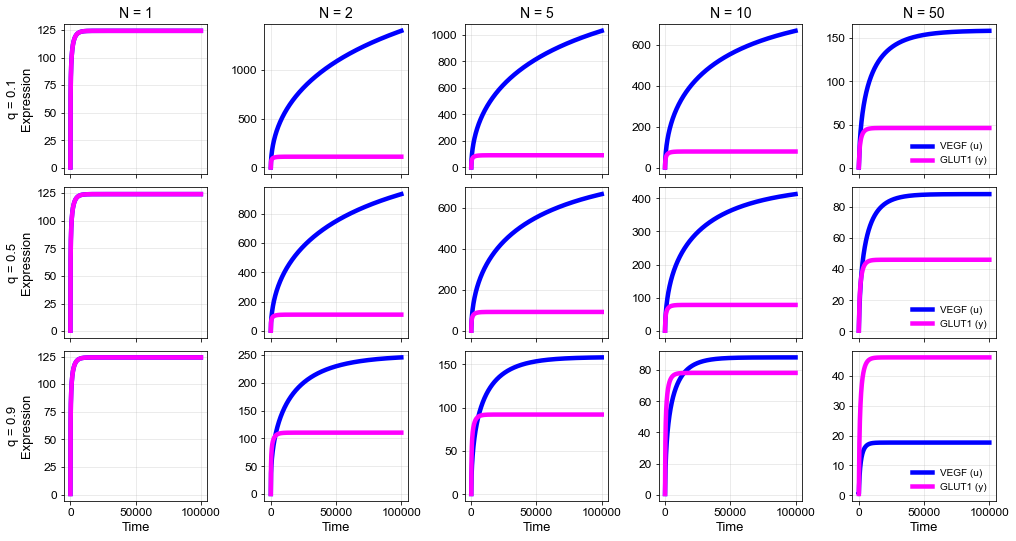

Saved ESS panel to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time\fixed_neighborhood_ess_panel_q_by_N.png


In [5]:

# ------------------------------ ESS panel --------------------------------
# Layout:
#   rows    = q in [0.1, 0.5, 0.9]
#   columns = N in [1, 2, 5, 10, 50]
# Each subplot overlays VEGF u(t) and GLUT1 y(t) using the manuscript colors.

fig, axes = plt.subplots(len(q_rows), len(N_values), figsize=(14, 7.4), sharex=True, sharey=False, constrained_layout=True)

for i, q in enumerate(q_rows):
    for j, N in enumerate(N_values):
        ax = axes[i, j]
        res = ess_results[(q, N)]
        ax.plot(res["t"], res["u"], color=VEGF_BLUE, label="VEGF (u)")
        ax.plot(res["t"], res["y"], color=GLUT_MAGENTA, label="GLUT1 (y)")

        if i == 0:
            ax.set_title(f"N = {N}")
        if j == 0:
            ax.set_ylabel(f"q = {q}\nExpression")
        if i == len(q_rows) - 1:
            ax.set_xlabel("Time")

        # Show the legend only on the rightmost column to match the compact panel style.
        if j == len(N_values) - 1:
            ax.legend(frameon=False, loc="best")

        ax.grid(True, alpha=0.3)

ess_panel_path = ESS_OUT_DIR / "fixed_neighborhood_ess_panel_q_by_N.png"
fig.savefig(ess_panel_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ESS panel to: {ess_panel_path}")


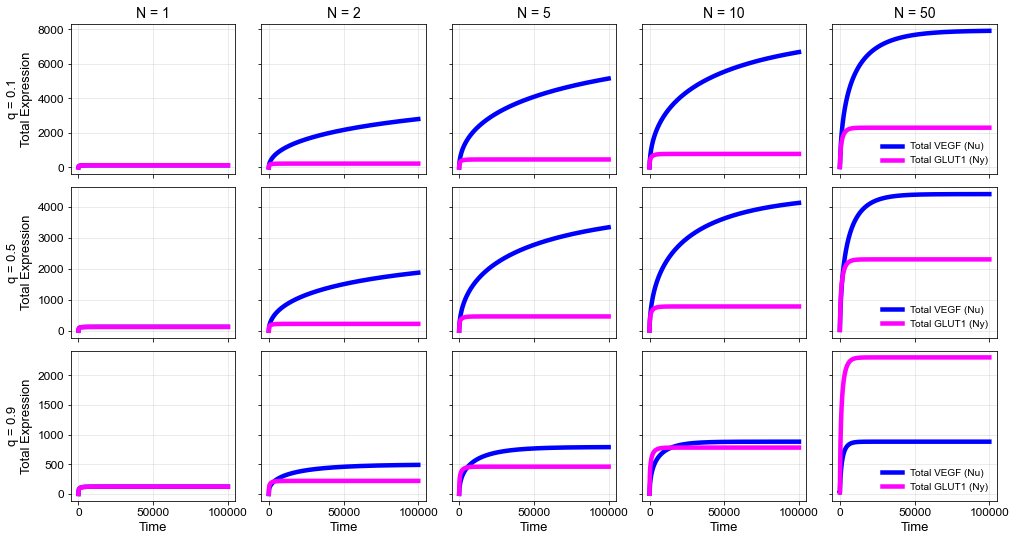

Saved ESS TOTAL panel to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time\fixed_neighborhood_ess_panel_q_by_N_total.png


In [6]:
# ------------------------------ ESS panel (TOTAL, row-shared y-axis) --------------------------------
# Each row (fixed q) shares the same y-axis

fig, axes = plt.subplots(
    len(q_rows),
    len(N_values),
    figsize=(14, 7.4),
    sharex=True,
    sharey='row',   # <-- KEY FIX
    constrained_layout=True
)

for i, q in enumerate(q_rows):
    for j, N in enumerate(N_values):
        ax = axes[i, j]
        res = ess_results[(q, N)]

        total_u = N * res["u"]
        total_y = N * res["y"]

        ax.plot(res["t"], total_u, color=VEGF_BLUE, label="Total VEGF (Nu)")
        ax.plot(res["t"], total_y, color=GLUT_MAGENTA, label="Total GLUT1 (Ny)")

        if i == 0:
            ax.set_title(f"N = {N}")
        if j == 0:
            ax.set_ylabel(f"q = {q}\nTotal Expression")
        if i == len(q_rows) - 1:
            ax.set_xlabel("Time")

        if j == len(N_values) - 1:
            ax.legend(frameon=False, loc="best")

        ax.grid(True, alpha=0.3)

ess_panel_total_path = ESS_OUT_DIR / "fixed_neighborhood_ess_panel_q_by_N_total.png"
fig.savefig(ess_panel_total_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ESS TOTAL panel to: {ess_panel_total_path}")


### ESS panel varying `q` at fixed `N`

This panel matches the manuscript-style layout:

- **top row:** VEGF trajectories `u(t)`
- **bottom row:** GLUT1 trajectories `y(t)`
- **left column:** `N = 1`
- **right column:** `N = 10`

Within each subplot, the curves vary across the resource-sharing values  
`q = 0.1, 0.3, 0.5, 0.7, 0.9`, using ordered blue and magenta palettes.


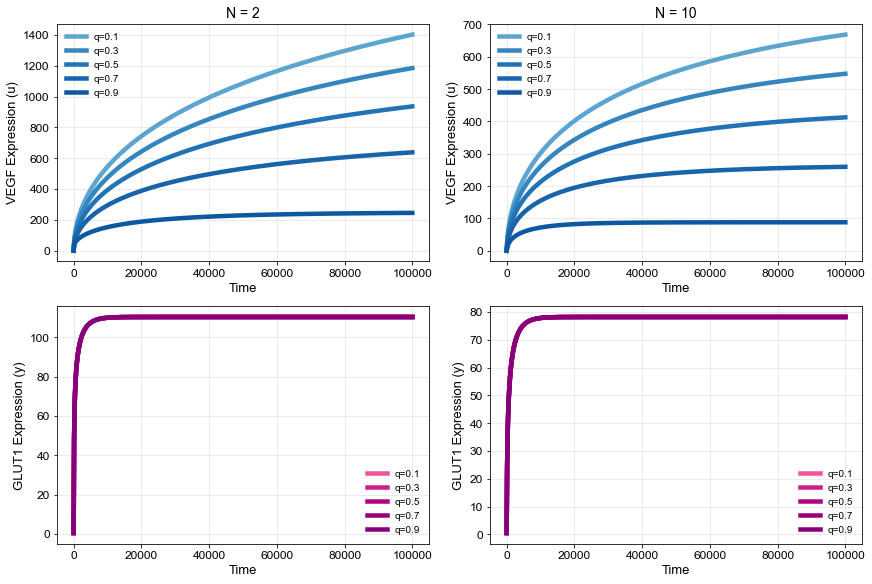

Saved ESS q-sweep panel to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time\fixed_neighborhood_ess_panel_vary_q_2x2.png


In [7]:

# ------------------------ ESS panel: vary q at fixed N ------------------------
# Layout:
#   top-left     = VEGF u(t) for N = 1, curves vary q
#   top-right    = VEGF u(t) for N = 10, curves vary q
#   bottom-left  = GLUT1 y(t) for N = 1, curves vary q
#   bottom-right = GLUT1 y(t) for N = 10, curves vary q

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Top row: VEGF
for col_idx, N in enumerate(N_rows):
    ax = axes[0, col_idx]
    for q in q_values:
        res = ess_results.get((q, N))
        if res is None:
            res = integrate_fixedN(q=q, N=N, p=p, u0=u0, y0=y0)
            ess_results[(q, N)] = res
        ax.plot(res["t"], res["u"], color=VEGF_Q_COLORS[q], label=f"q={q:g}")

    ax.set_title(f"N = {N}")
    ax.set_xlabel("Time")
    ax.set_ylabel("VEGF Expression (u)")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

# Bottom row: GLUT1
for col_idx, N in enumerate(N_rows):
    ax = axes[1, col_idx]
    for q in q_values:
        res = ess_results[(q, N)]
        ax.plot(res["t"], res["y"], color=GLUT_Q_COLORS[q], label=f"q={q:g}")

    ax.set_xlabel("Time")
    ax.set_ylabel("GLUT1 Expression (y)")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

ess_panel_b_path = ESS_OUT_DIR / "fixed_neighborhood_ess_panel_vary_q_2x2.png"
fig.savefig(ess_panel_b_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ESS q-sweep panel to: {ess_panel_b_path}")


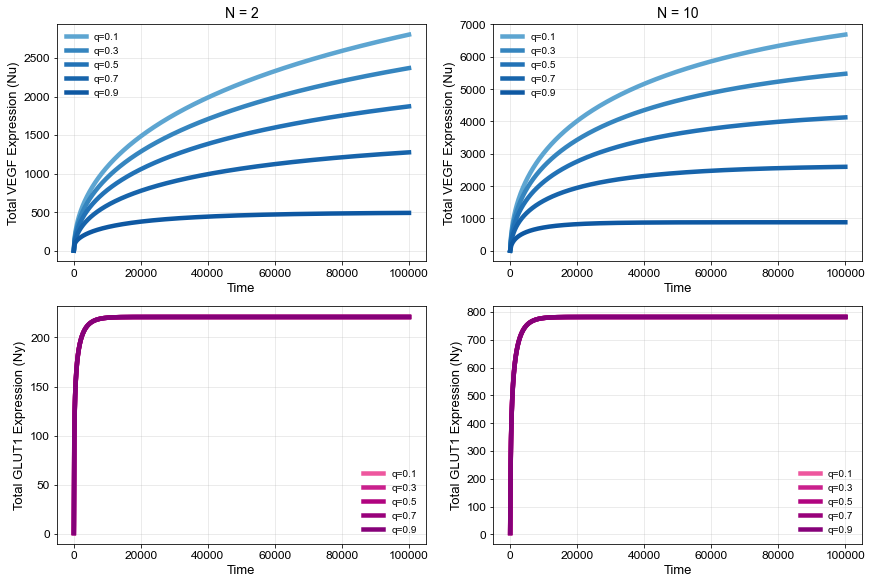

Saved ESS TOTAL q-sweep panel to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\ESS_dynamics\long_eqb_time\fixed_neighborhood_ess_panel_vary_q_2x2_total.png


In [8]:
# ------------------------ ESS panel (TOTAL): vary q at fixed N ------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Top row: VEGF (total)
for col_idx, N in enumerate(N_rows):
    ax = axes[0, col_idx]
    for q in q_values:
        res = ess_results.get((q, N))
        if res is None:
            res = integrate_fixedN(q=q, N=N, p=p, u0=u0, y0=y0)
            ess_results[(q, N)] = res

        total_u = N * res["u"]
        ax.plot(res["t"], total_u, color=VEGF_Q_COLORS[q], label=f"q={q:g}")

    ax.set_title(f"N = {N}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Total VEGF Expression (Nu)")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

# Bottom row: GLUT1 (total)
for col_idx, N in enumerate(N_rows):
    ax = axes[1, col_idx]
    for q in q_values:
        res = ess_results[(q, N)]

        total_y = N * res["y"]
        ax.plot(res["t"], total_y, color=GLUT_Q_COLORS[q], label=f"q={q:g}")

    ax.set_xlabel("Time")
    ax.set_ylabel("Total GLUT1 Expression (Ny)")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

ess_panel_b_total_path = ESS_OUT_DIR / "fixed_neighborhood_ess_panel_vary_q_2x2_total.png"
fig.savefig(ess_panel_b_total_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ESS TOTAL q-sweep panel to: {ess_panel_b_total_path}")


## Team Optimum dynamics

The Team Optimum simulations use the same baseline parameter set but replace the ESS gradients with the corresponding Team Optimum gradients.

The plotting layout below is streamlined to match the manuscript-style figures:

- a **1 × 2 panel** where the curves vary across neighborhood size `N`
- a **1 × 5 overlay panel** where each subplot corresponds to one value of `N`

The next cell:
- runs the Team Optimum trajectories across the same set of neighborhood sizes
- saves the trajectories to a combined workbook
- stores them for the plotting cells below


In [9]:

# ------------------------ Team Optimum simulations ------------------------
# You can override only the final integration time here if needed.
p_TO = apply_overrides(p, t_max=12000.0)

to_runs = []
to_results = {}

for N in N_values:
    res = integrate_teamopt(q=0.0, N=N, p=p_TO, u0=u0, y0=y0)  # q kept only for API symmetry
    to_results[N] = res
    to_runs.append({
        "sheet": f"N={int(N)}",
        "t": res["t"],
        "u": res["u"],
        "y": res["y"],
    })

to_workbook = TO_OUT_DIR / "fixed_neighborhood_team_opt_vary_N_data.xlsx"
to_params = to_dict(p_TO)
to_params.update({
    "u0": u0,
    "y0": y0,
    "N_values": N_values,
})
write_panel_workbook(to_workbook, to_params, to_runs)

print(f"Saved Team Optimum workbook to: {to_workbook}")
print(f"Stored {len(to_runs)} Team Optimum trajectories.")


Saved Team Optimum workbook to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time\fixed_neighborhood_team_opt_vary_N_data.xlsx
Stored 5 Team Optimum trajectories.


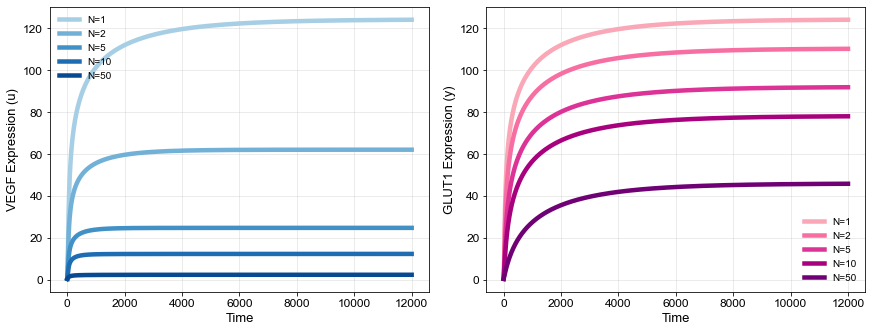

Saved Team Optimum panel A to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time\fixed_neighborhood_team_opt_panel_A.png


In [10]:

# -------------------------- Team Optimum panel A --------------------------
# One row, two columns:
#   left  = VEGF u(t), curves vary N
#   right = GLUT1 y(t), curves vary N

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for N in N_values:
    res = to_results[N]
    axes[0].plot(res["t"], res["u"], color=VEGF_N_COLORS[N], label=f"N={N}")
    axes[1].plot(res["t"], res["y"], color=GLUT_N_COLORS[N], label=f"N={N}")

axes[0].set_xlabel("Time")
axes[1].set_xlabel("Time")
axes[0].set_ylabel("VEGF Expression (u)")
axes[1].set_ylabel("GLUT1 Expression (y)")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)

to_panel_a_path = TO_OUT_DIR / "fixed_neighborhood_team_opt_panel_A.png"
fig.savefig(to_panel_a_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Team Optimum panel A to: {to_panel_a_path}")


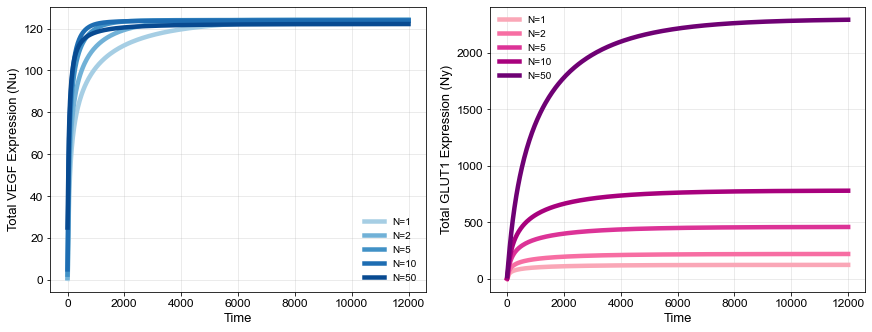

Saved Team Optimum TOTAL panel A to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time\fixed_neighborhood_team_opt_panel_A_total.png


In [11]:
# -------------------------- Team Optimum panel A (TOTAL expression) --------------------------
# Same layout as panel A, but plotting:
#   Total VEGF = N * u
#   Total GLUT1 = N * y

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for N in N_values:
    res = to_results[N]

    total_u = N * res["u"]
    total_y = N * res["y"]

    axes[0].plot(res["t"], total_u, color=VEGF_N_COLORS[N], label=f"N={N}")
    axes[1].plot(res["t"], total_y, color=GLUT_N_COLORS[N], label=f"N={N}")

axes[0].set_xlabel("Time")
axes[1].set_xlabel("Time")
axes[0].set_ylabel("Total VEGF Expression (Nu)")
axes[1].set_ylabel("Total GLUT1 Expression (Ny)")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)

to_panel_a_total_path = TO_OUT_DIR / "fixed_neighborhood_team_opt_panel_A_total.png"
fig.savefig(to_panel_a_total_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Team Optimum TOTAL panel A to: {to_panel_a_total_path}")

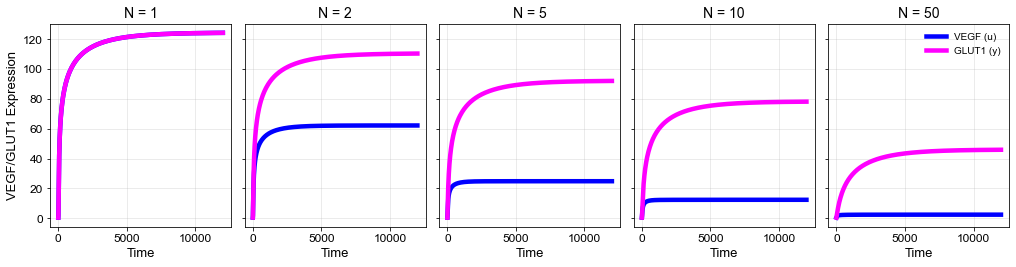

Saved Team Optimum panel C to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time\fixed_neighborhood_team_opt_panel_C.png


In [12]:

# -------------------------- Team Optimum panel C --------------------------
# One row, five columns:
#   each subplot corresponds to one N
#   within each subplot, VEGF and GLUT1 are overlaid using the fixed manuscript colors

fig, axes = plt.subplots(1, len(N_values), figsize=(14, 3.6), sharey=True, constrained_layout=True)

for j, (ax, N) in enumerate(zip(axes, N_values)):
    res = to_results[N]
    ax.plot(res["t"], res["u"], color=VEGF_BLUE, label="VEGF (u)")
    ax.plot(res["t"], res["y"], color=GLUT_MAGENTA, label="GLUT1 (y)")
    ax.set_title(f"N = {N}")
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

    # Show legends only on the rightmost subplot to keep the panel uncluttered.
    if j == len(N_values) - 1:
        ax.legend(frameon=False, loc="best")

axes[0].set_ylabel("VEGF/GLUT1 Expression")

to_panel_c_path = TO_OUT_DIR / "fixed_neighborhood_team_opt_panel_C.png"
fig.savefig(to_panel_c_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Team Optimum panel C to: {to_panel_c_path}")


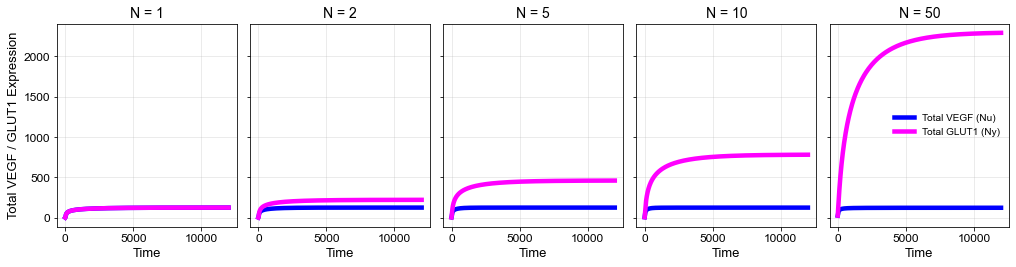

Saved Team Optimum TOTAL panel C to: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\fixed_neighborhoods\team_opt_dynamics\long_eqb_time\fixed_neighborhood_team_opt_panel_C_total.png


In [13]:
# -------------------------- Team Optimum panel C (TOTAL expression) --------------------------
# Same layout as panel C, but plotting total expression:
#   Total VEGF = N * u
#   Total GLUT1 = N * y

fig, axes = plt.subplots(1, len(N_values), figsize=(14, 3.6), sharey=True, constrained_layout=True)

for j, (ax, N) in enumerate(zip(axes, N_values)):
    res = to_results[N]

    # Multiply by N
    total_u = N * res["u"]
    total_y = N * res["y"]

    ax.plot(res["t"], total_u, color=VEGF_BLUE, label="Total VEGF (Nu)")
    ax.plot(res["t"], total_y, color=GLUT_MAGENTA, label="Total GLUT1 (Ny)")

    ax.set_title(f"N = {N}")
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

    # Legend only on last subplot
    if j == len(N_values) - 1:
        ax.legend(frameon=False, loc="best")

axes[0].set_ylabel("Total VEGF / GLUT1 Expression")

to_panel_c_total_path = TO_OUT_DIR / "fixed_neighborhood_team_opt_panel_C_total.png"
fig.savefig(to_panel_c_total_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Team Optimum TOTAL panel C to: {to_panel_c_total_path}")